In [1]:
import pandas as pd

file_path = r"C:\Users\USER\Downloads\Telco_Customer_Churn.csv"

# Loading the Telco_customer_churn_dataset
df = pd.read_csv(file_path)

# Displaying the first 10 rows 
print("--- FIRST 10 ROWS ---")
print(df.head(10))

# Identifying the data types 
print("\n--- DATA TYPES ---")
print(df.dtypes)

# Checking for missing values 
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

--- FIRST 10 ROWS ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service  

In [2]:
# Standardizing Column names 

df.columns = df.columns.str.lower().str.replace(' ','_')

print("---Standardized Column Names ---")
print(df.columns.tolist())
print("-" * 30)

# Removing Duplicate Records 

initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]
duplicates_removed = initial_rows - final_rows 

print(f"Duplicates handled: Remove {duplicates_removed} duplicate row(s).")
print(f"Remaining dataset rows: {final_rows}")
print("-" * 30)

# From task 1 there are no missing values 

print(f"Missing Values Checked: Clean (0 missing values found)")

---Standardized Column Names ---
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']
------------------------------
Duplicates handled: Remove 0 duplicate row(s).
Remaining dataset rows: 7043
------------------------------
Missing Values Checked: Clean (0 missing values found)


---SUMMARY STATISTICS (MEAN & MEDIAN) ---
      seniorcitizen     tenure  monthlycharges  totalcharges
mean       0.162147  32.371149       64.761692   2283.300441
50%        0.000000  29.000000       70.350000   1397.475000
------------------------------------------------------------
--- SUMMARY STATISTICS (MODE) ---
tenure             1.00
monthlycharges    20.05
totalcharges      20.20
Name: 0, dtype: float64
--- CHURN RATE ANALYSIS ---
churn = No: 5174 customers(73.46%)
churn = Yes: 1869 customers(26.54%)


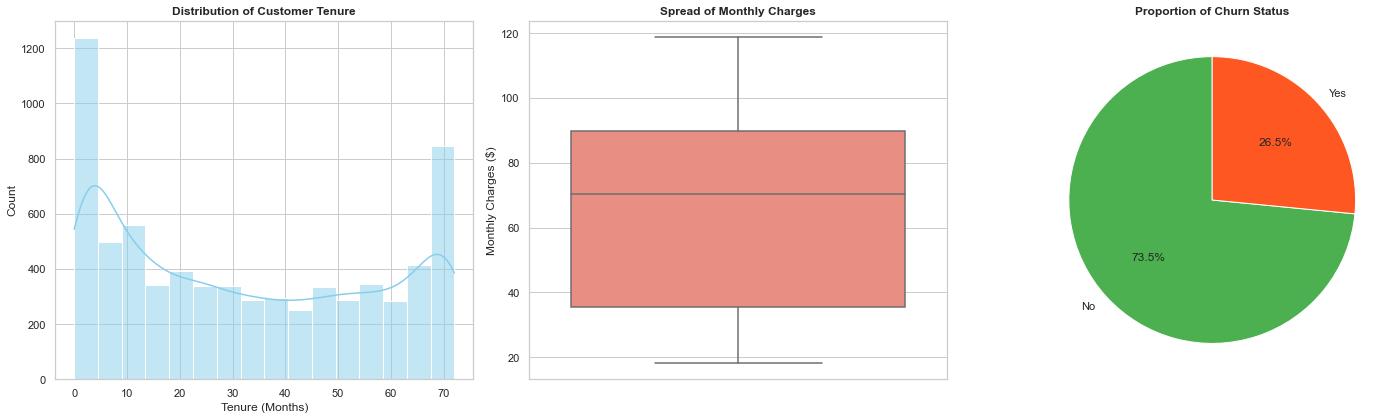

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

# Setting visual style for all charts 
sns.set_theme(style="whitegrid")

# Ensuring Total Charges is numeric so it can be used for summary statistics
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# SUMMARY STATISTICS 

print("---SUMMARY STATISTICS (MEAN & MEDIAN) ---")
print(df.describe().loc[['mean', '50%']])
print("-" * 60)

print("--- SUMMARY STATISTICS (MODE) ---")
print(df[['tenure', 'monthlycharges', 'totalcharges']].mode().iloc[0])
print('=' * 60)

# CHURN RATE ANALYSIS 

churn_counts = df['churn'].value_counts()
churn_proportions = df['churn'].value_counts(normalize=True) * 100

print("--- CHURN RATE ANALYSIS ---")
for status in churn_counts.index: 
    print(f"churn = {status}: {churn_counts[status]} customers({churn_proportions[status]:.2f}%)")
print("=" * 60)

# VISUALIZATIONS (DISTRIBUTION & CHURN)
# =====================================
# Creating a clean layout: 1 row with 3 distinct subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tenure Distribution 
sns.histplot(data=df, x='tenure', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Customer Tenure', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')

# Monthly Charges (Detecting Outliers)
sns.boxplot(data=df, y='monthlycharges', ax=axes[1], color='salmon')
axes[1].set_title('Spread of Monthly Charges', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')

# Churn vs. Non-Churn Proportions
axes[2].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF5722'])
axes[2].set_title('Proportion of Churn Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

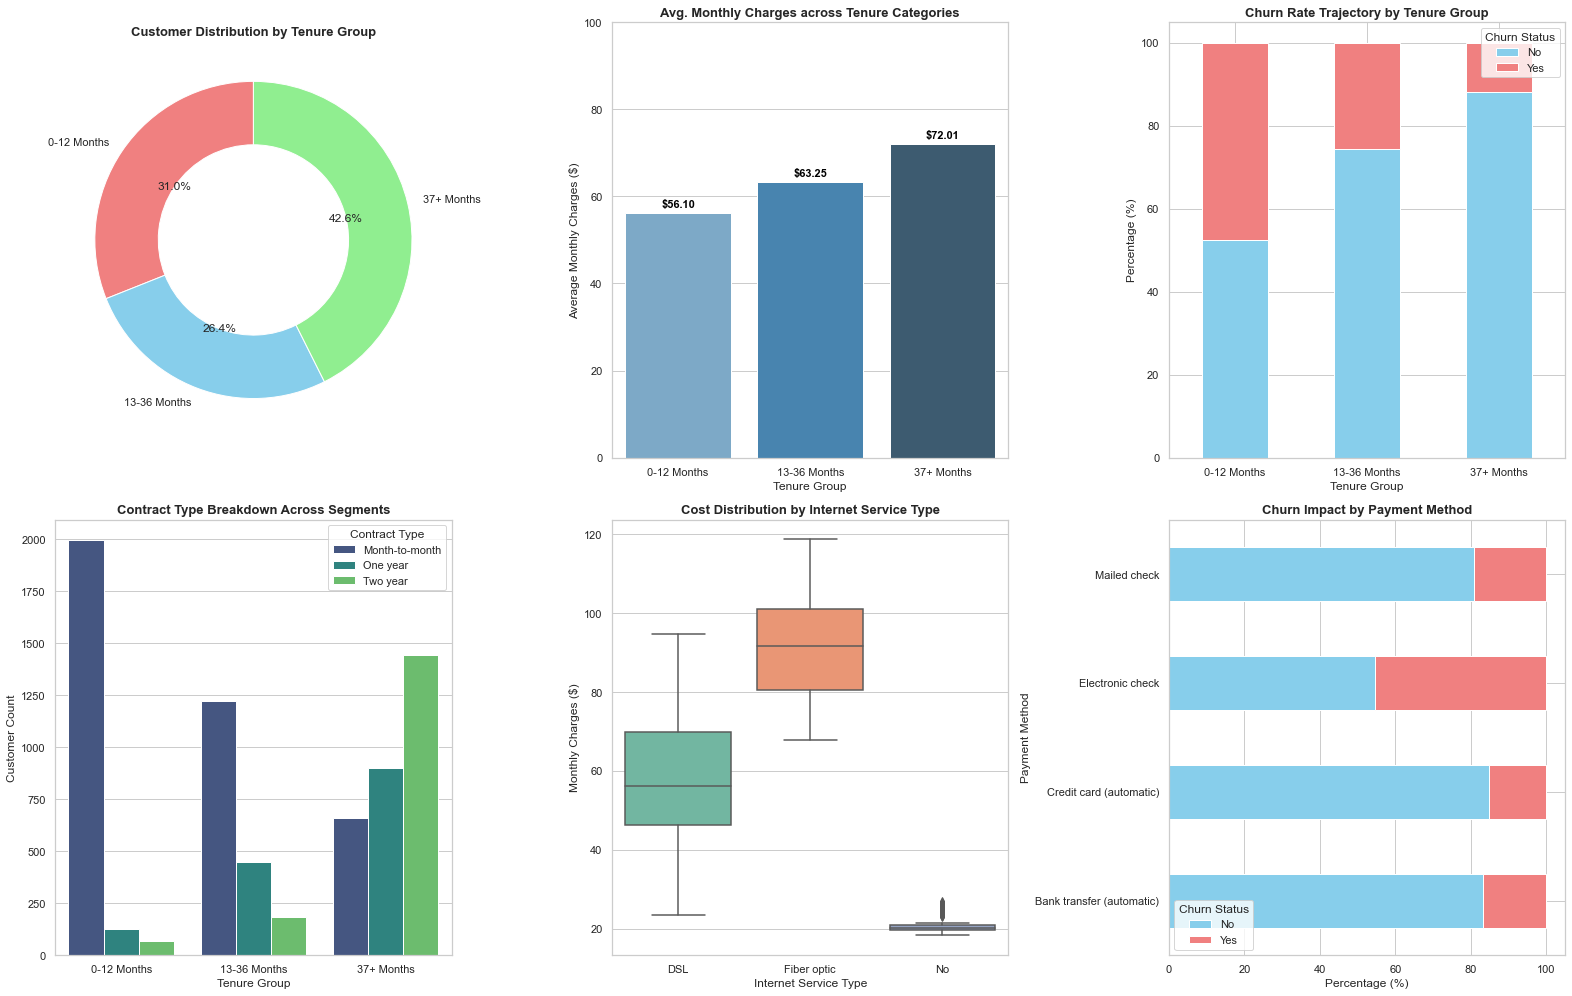

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd
import numpy as np 

# Style setting 
sns.set_theme(style="whitegrid")

# Data Segmentation 
# ===============================
# Defining the tenure bins and clear labels 
bins = [0, 12, 36, df['tenure'].max()]
labels = ['0-12 Months','13-36 Months','37+ Months']

# Creating a new categorical column for segments 
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# TENURE CHART
# ===============================
tenure_counts = df['tenure_group'].value_counts().reindex(labels)

fig, axes = plt.subplots(2, 3,figsize=(22, 14))
axes[0, 0].pie(tenure_counts, labels=tenure_counts.index, autopct='%1.1f%%',
              startangle=90, colors=['lightcoral','skyblue','lightgreen'],
              wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0, 0].set_title('Customer Distribution by Tenure Group', fontsize=13, fontweight='bold')

# MONTHLY CHARGES BY TENURE 
# ===============================
# Calculate mean monthly charges per group 
avg_charge = df.groupby('tenure_group', observed=False)['monthlycharges'].mean().reset_index()

sns.barplot(data=avg_charge, x='tenure_group', y='monthlycharges', ax=axes[0, 1], palette='Blues_d')
axes[0, 1].set_title('Avg. Monthly Charges across Tenure Categories', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Tenure Group')
axes[0, 1].set_ylabel('Average Monthly Charges ($)')
axes[0, 1].set_ylim(0, 100) 

# Adding annotations on top of bars
for p in axes[0, 1].patches:
    height = p.get_height()
    x_pos = p.get_x() + p.get_width() / 2.
    axes[0, 1].annotate(f"${height:.2f}", (x_pos, height + 2), ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    
# ===============================
# CHURN RATE BY TENURE GROUP 
churn_by_tenure = df.groupby('tenure_group', observed=False)['churn'].value_counts(normalize=True).unstack() * 100

churn_by_tenure.plot(kind='bar', stacked=True, ax=axes[0, 2], color=['skyblue', 'lightcoral'])
axes[0, 2].set_title('Churn Rate Trajectory by Tenure Group', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Tenure Group')
axes[0, 2].set_ylabel('Percentage (%)')
axes[0, 2].legend(title='Churn Status', loc='upper right')
axes[0, 2].tick_params(axis='x', rotation=0)

# CONTRACT TYPE DISTRIBUTION BY TENURE GROUP
# ================================
# Highlighting if long-tenure are tied to safer contract structures 
sns.countplot(data=df, x='tenure_group', hue='contract', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Contract Type Breakdown Across Segments', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Tenure Group')
axes[1, 0].set_ylabel('Customer Count')
axes[1, 0].legend(title='Contract Type')

# INTERNET SERVICE TYPE VS MONTHLY CHARGES
# =================================
# Revealing what service choice is causing higher average bills 
sns.boxplot(data=df, x='internetservice', y='monthlycharges', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Cost Distribution by Internet Service Type', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Internet Service Type')
axes[1, 1].set_ylabel('Monthly Charges ($)')

# CHURN RATE BY PAYMENT METHOD
pay_churn = df.groupby('paymentmethod', observed=False)['churn'].value_counts(normalize=True).unstack() * 100

pay_churn.plot(kind='barh', stacked=True, ax=axes[1, 2], color=['skyblue', 'lightcoral'])
axes[1, 2].set_title('Churn Impact by Payment Method', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Percentage (%)')
axes[1, 2].set_ylabel('Payment Method')
axes[1, 2].legend(title='Churn Status', loc='lower left')


plt.tight_layout()
plt.show()

